# Lab Experiment 7: Decision Tree Classifier on the Iris Dataset
Amogh Sahore<br>
2547108<br>
Lab 07<br>

**Aim:** To build, evaluate, visualize, and tune a Decision Tree classifier using Scikit-learn's Iris dataset.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

RANDOM_STATE = 42

## Task 1: Dataset Exploration

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = [class_names[label] for label in y]

print('Number of samples:', X.shape[0])
print('Number of features:', X.shape[1])
print('Feature names:', feature_names)
print('Target classes:', class_names)
display(iris_df.head())
display(iris_df['species'].value_counts().rename_axis('Species').reset_index(name='Count'))

Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


,Species,Count
0,setosa,50
1,versicolor,50
2,virginica,50


**Inference:** The Iris dataset has 150 samples and 4 numerical flower measurements. It contains three classes: setosa, versicolor, and virginica. Each class has 50 samples, so the dataset is balanced.

## Task 2: Data Preparation

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training set shape: (120, 4)
Testing set shape: (30, 4)
Training samples: 120
Testing samples: 30


**Inference:** The data is divided into 80% training and 20% testing samples. Training data is used to build the model, while testing data checks how well it works on unseen flowers. Stratification keeps all three classes represented in both sets.

## Task 3: Build and Evaluate a Default Decision Tree

In [4]:
# Default parameters are used as required in the task.
default_tree = DecisionTreeClassifier()
default_tree.fit(X_train, y_train)
default_pred = default_tree.predict(X_test)

default_accuracy = accuracy_score(y_test, default_pred)
print(f'Accuracy Score: {default_accuracy:.4f}')

cm = confusion_matrix(y_test, default_pred)
display(pd.DataFrame(cm, index=class_names, columns=class_names))

print('Classification Report:')
print(classification_report(y_test, default_pred, target_names=class_names))

Accuracy Score: 0.9333


,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,1
virginica,0,1,9


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



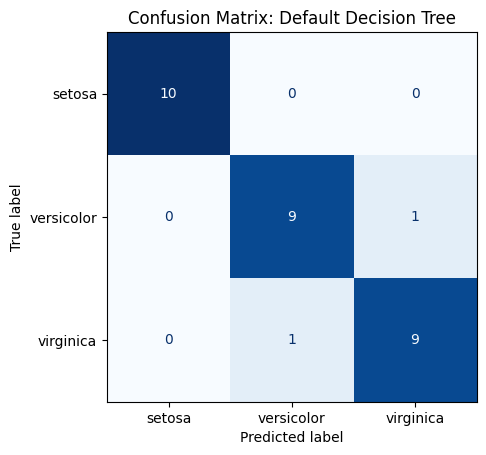

In [5]:
display_plot = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display_plot.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix: Default Decision Tree')
plt.grid(False)
plt.show()

**Inference:** Accuracy shows the total correct predictions. The confusion matrix shows which flower classes were predicted correctly or confused with another class. The classification report gives precision, recall, and F1-score for each class.

## Task 4: Visualize and Inspect the Decision Tree

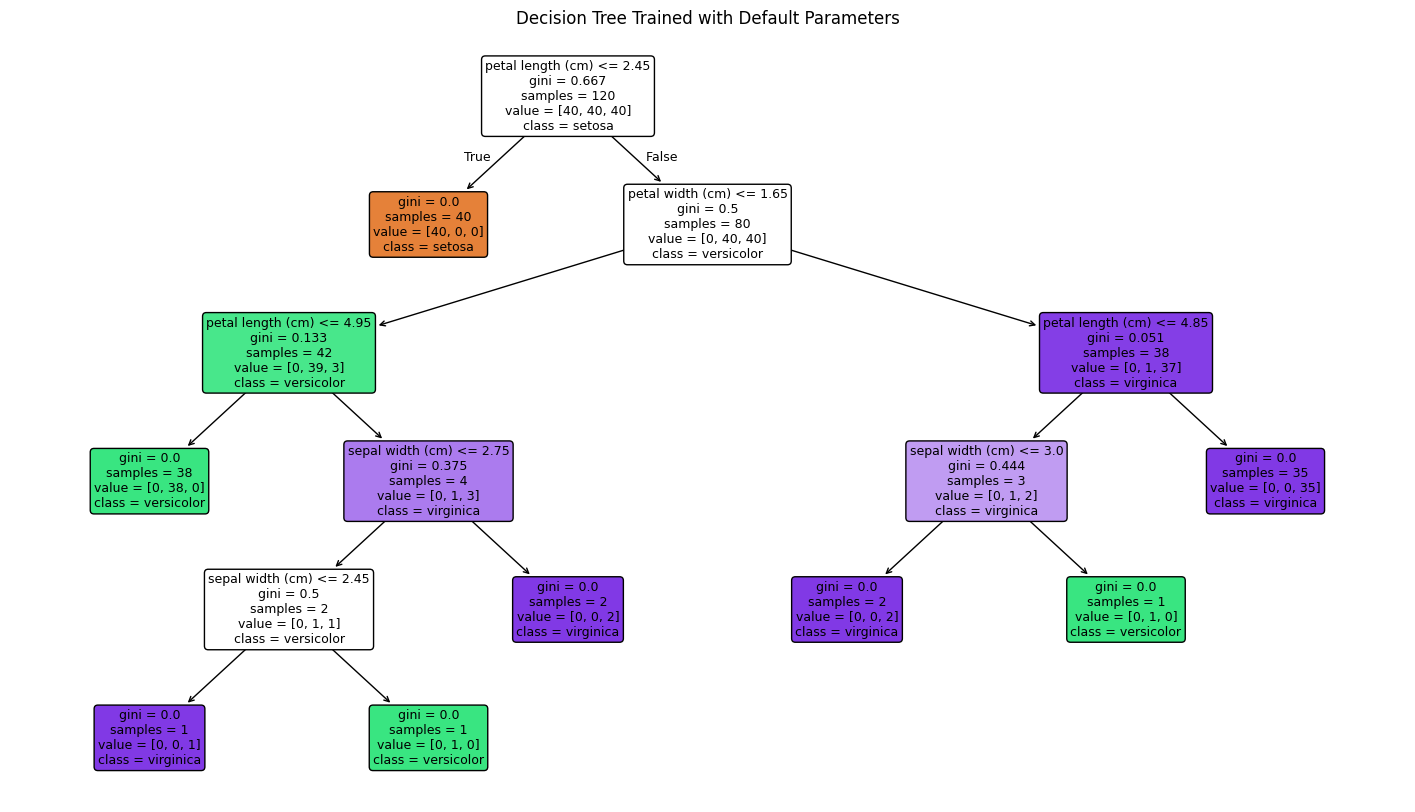

Root node: Node 0
Number of internal nodes: 7
Number of leaf nodes: 8
Maximum tree depth: 5
Feature selected for the first split: petal length (cm)


In [6]:
plt.figure(figsize=(18, 10))
plot_tree(
    default_tree, feature_names=feature_names, class_names=class_names,
    filled=True, rounded=True, fontsize=9
)
plt.title('Decision Tree Trained with Default Parameters')
plt.show()

tree_structure = default_tree.tree_
is_leaf = tree_structure.children_left == tree_structure.children_right
internal_node_count = np.sum(~is_leaf)
leaf_node_count = np.sum(is_leaf)
root_feature_index = tree_structure.feature[0]
root_feature = feature_names[root_feature_index]

print('Root node: Node 0')
print('Number of internal nodes:', internal_node_count)
print('Number of leaf nodes:', leaf_node_count)
print('Maximum tree depth:', default_tree.get_depth())
print('Feature selected for the first split:', root_feature)

**Inference:** The root node is the top node in the plot, internal nodes make further splits, and leaf nodes give the final class prediction. The first-split feature printed above was chosen because it gives the highest reduction in class impurity at that stage.

## Task 5: Compare Gini Index and Entropy

In [7]:
def root_feature_name(model):
    return feature_names[model.tree_.feature[0]]

criterion_models = {}
criterion_rows = []
for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    criterion_models[criterion] = model
    criterion_rows.append({
        'Criterion': criterion.capitalize(),
        'Accuracy': accuracy_score(y_test, model.predict(X_test)),
        'Tree Depth': model.get_depth(),
        'Leaf Nodes': model.get_n_leaves(),
        'Root Feature': root_feature_name(model)
    })

criterion_results = pd.DataFrame(criterion_rows)
display(criterion_results.round({'Accuracy': 4}))

ranked_criteria = criterion_results.sort_values(['Tree Depth', 'Leaf Nodes'])
best_depth = ranked_criteria.iloc[0]['Tree Depth']
best_leaf_count = ranked_criteria.iloc[0]['Leaf Nodes']
simplest_models = ranked_criteria[
    (ranked_criteria['Tree Depth'] == best_depth) &
    (ranked_criteria['Leaf Nodes'] == best_leaf_count)
]

if len(simplest_models) == 1:
    print(f"Simpler tree based on depth and leaf nodes: {simplest_models.iloc[0]['Criterion']}")
else:
    print(
        'Neither criterion produced a simpler tree: '
        f"{', '.join(simplest_models['Criterion'])} tied "
        f"(depth={best_depth}, leaf nodes={best_leaf_count})."
    )

,Criterion,Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,Gini,0.9333,5,8,petal length (cm)
1,Entropy,0.9333,5,8,petal length (cm)


Neither criterion produced a simpler tree: Gini, Entropy tied (depth=5, leaf nodes=8).


**Inference:** Gini and entropy are two methods for measuring node impurity. A simpler tree has lower depth and fewer leaf nodes. In this experiment, both criteria produced the same depth (5), number of leaf nodes (8), root feature, and accuracy (0.9333), so neither is simpler; the result is a tie. Their performance can be compared directly because both models use the same train/test split.

## Task 6: Effect of Maximum Tree Depth

In [8]:
def depth_observation(train_accuracy, test_accuracy):
    gap = train_accuracy - test_accuracy
    if train_accuracy < 0.90:
        return 'Likely underfitting'
    if gap > 0.08:
        return 'Possible overfitting'
    return 'Good balance'

depth_rows = []
for max_depth in [1, 2, 3, 4, None]:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    depth_rows.append({
        'Max Depth': 'None' if max_depth is None else max_depth,
        'Training Accuracy': train_accuracy,
        'Testing Accuracy': test_accuracy,
        'Tree Depth': model.get_depth(),
        'Observation': depth_observation(train_accuracy, test_accuracy)
    })

depth_results = pd.DataFrame(depth_rows)
display(depth_results.round({'Training Accuracy': 4, 'Testing Accuracy': 4}))

underfit_model = depth_results.sort_values('Training Accuracy').iloc[0]
best_generalization_model = depth_results.sort_values(['Testing Accuracy', 'Training Accuracy'], ascending=False).iloc[0]
depth_results['Accuracy Gap'] = depth_results['Training Accuracy'] - depth_results['Testing Accuracy']
overfit_model = depth_results.sort_values('Accuracy Gap', ascending=False).iloc[0]

print('Underfitting model:', underfit_model['Max Depth'])
print('Best generalization model:', best_generalization_model['Max Depth'])
print('Most likely overfitting model:', overfit_model['Max Depth'])

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth,Observation
0,1,0.6667,0.6667,1,Likely underfitting
1,2,0.9667,0.9333,2,Good balance
2,3,0.9833,0.9667,3,Good balance
3,4,0.9917,0.9333,4,Good balance
4,None,1.0000,0.9333,5,Good balance


Underfitting model: 1
Best generalization model: 3
Most likely overfitting model: None


**Inference:** A very shallow tree usually underfits because it cannot separate all three classes well. The best-generalization model has the highest testing accuracy. A large difference between training and testing accuracy suggests overfitting.

## Task 7: Effect of `min_samples_split`

In [9]:
split_rows = []
for min_split in [2, 5, 10, 20]:
    model = DecisionTreeClassifier(min_samples_split=min_split, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    split_rows.append({
        'min_samples_split': min_split,
        'Accuracy': accuracy_score(y_test, model.predict(X_test)),
        'Tree Depth': model.get_depth(),
        'Leaf Nodes': model.get_n_leaves()
    })

split_results = pd.DataFrame(split_rows)
baseline_depth = split_results.loc[0, 'Tree Depth']
split_results['Observation'] = np.where(
    split_results['Tree Depth'] < baseline_depth, 'Simpler tree', 'Similar complexity'
)
display(split_results.round({'Accuracy': 4}))

,min_samples_split,Accuracy,Tree Depth,Leaf Nodes,Observation
0,2,0.9333,5,8,Similar complexity
1,5,0.9667,3,5,Simpler tree
2,10,0.9667,3,5,Simpler tree
3,20,0.9667,3,5,Simpler tree


**Inference:** Increasing `min_samples_split` requires more samples before a node can split. This usually reduces tree depth and leaf nodes, making the tree simpler. If the value is too high, the model may underfit.

## Task 8: Effect of `min_samples_leaf`

In [10]:
leaf_rows = []
for min_leaf in [1, 2, 5, 10]:
    model = DecisionTreeClassifier(min_samples_leaf=min_leaf, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    leaf_rows.append({
        'min_samples_leaf': min_leaf,
        'Accuracy': accuracy_score(y_test, model.predict(X_test)),
        'Tree Depth': model.get_depth(),
        'Leaf Nodes': model.get_n_leaves()
    })

leaf_results = pd.DataFrame(leaf_rows)
baseline_leaves = leaf_results.loc[0, 'Leaf Nodes']
leaf_results['Observation'] = np.where(
    leaf_results['Leaf Nodes'] < baseline_leaves, 'Less complex tree', 'Baseline complexity'
)
display(leaf_results.round({'Accuracy': 4}))

,min_samples_leaf,Accuracy,Tree Depth,Leaf Nodes,Observation
0,1,0.9333,5,8,Baseline complexity
1,2,0.9333,4,6,Less complex tree
2,5,0.9333,3,5,Less complex tree
3,10,0.9333,3,5,Less complex tree


**Inference:** Increasing `min_samples_leaf` forces each leaf to contain more training samples. This prevents the tree from making rules for very small groups, so it can reduce overfitting. Very large values can make the model too simple.

## Task 9: Final Answers and Recommendation

In [11]:
impact_summary = pd.DataFrame({
    'Hyperparameter': ['max_depth', 'min_samples_split', 'min_samples_leaf'],
    'Testing Accuracy Range': [
        depth_results['Testing Accuracy'].max() - depth_results['Testing Accuracy'].min(),
        split_results['Accuracy'].max() - split_results['Accuracy'].min(),
        leaf_results['Accuracy'].max() - leaf_results['Accuracy'].min()
    ]
})
display(impact_summary.round(4))

greatest_impact = impact_summary.sort_values('Testing Accuracy Range', ascending=False).iloc[0]['Hyperparameter']
recommended_depth = best_generalization_model['Max Depth']
print(f'Hyperparameter with greatest observed impact: {greatest_impact}')
print(f'Recommended max_depth setting from this experiment: {recommended_depth}')

,Hyperparameter,Testing Accuracy Range
0,max_depth,0.3000
1,min_samples_split,0.0333
2,min_samples_leaf,0.0000


Hyperparameter with greatest observed impact: max_depth
Recommended max_depth setting from this experiment: 3


**Answers:**

1. `criterion` decides how the tree measures impurity when selecting a split. Gini and entropy both prefer purer child nodes.
2. A small `max_depth` can underfit, while a very large or unlimited depth can overfit by memorising training patterns.
3. Larger `min_samples_split` and `min_samples_leaf` values restrict splitting, so they produce simpler trees with fewer leaves.
4. The code above identifies the hyperparameter with the largest observed testing-accuracy range. This is used as evidence for the greatest impact.
5. The recommended model is the depth setting printed above because it has the best testing accuracy in this experiment.

## Conclusion

**Conclusion:** The Decision Tree classifier can classify Iris flowers using four measurements. The experiments show that tree complexity must be controlled to balance underfitting and overfitting. The recommended setting is chosen from the testing results, not only from training accuracy.